# PCA + TNSE

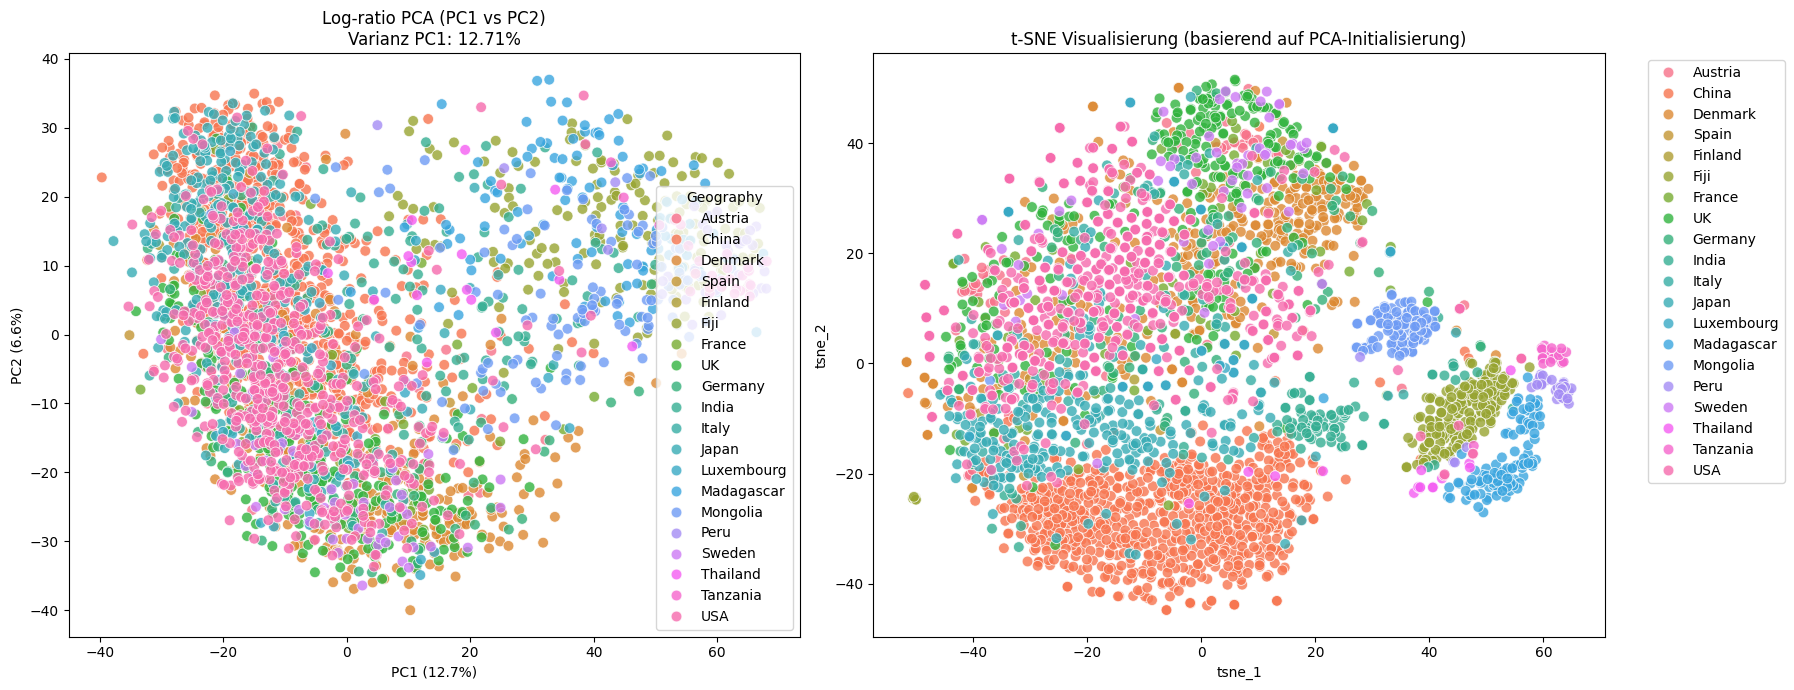

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Daten laden
# Ersetze den Pfad durch deine tatsächliche Datei
file_path = '../data/processed/06_clr_healthy_data.csv'
df = pd.read_csv(file_path)

# Drop all columns that dont start with "msp" and Geography
df = df[df.columns[df.columns.str.startswith('msp') | df.columns.str.startswith('Geography')]]

# Identify features and labels
features = [col for col in df.columns if col.startswith('msp')]


X = df[features]
labels = df['Geography']  # Deine Zielvariable für die Einfärbung

# 2. PCA durchführen
# Wir reduzieren zuerst auf z.B. 50 Komponenten, um Rauschen zu filtern
pca = PCA(n_components=0.95) # Behält 95% der Varianz
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
df_pca['Geography'] = labels

# 3. t-SNE durchführen
# Best Practice: t-SNE auf den PCA-Ergebnissen berechnen
tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=42)
X_tsne = tsne.fit_transform(X_pca)

df_tsne = pd.DataFrame(X_tsne, columns=['tsne_1', 'tsne_2'])
df_tsne['Geography'] = labels

# 4. Visualisierung
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot PCA
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Geography', ax=ax1, palette='husl', s=60, alpha=0.8)
ax1.set_title(f'Log-ratio PCA (PC1 vs PC2)\nVarianz PC1: {pca.explained_variance_ratio_[0]:.2%}')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

# Plot t-SNE
sns.scatterplot(data=df_tsne, x='tsne_1', y='tsne_2', hue='Geography', ax=ax2, palette='husl', s=60, alpha=0.8)
ax2.set_title('t-SNE Visualisierung (basierend auf PCA-Initialisierung)')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()




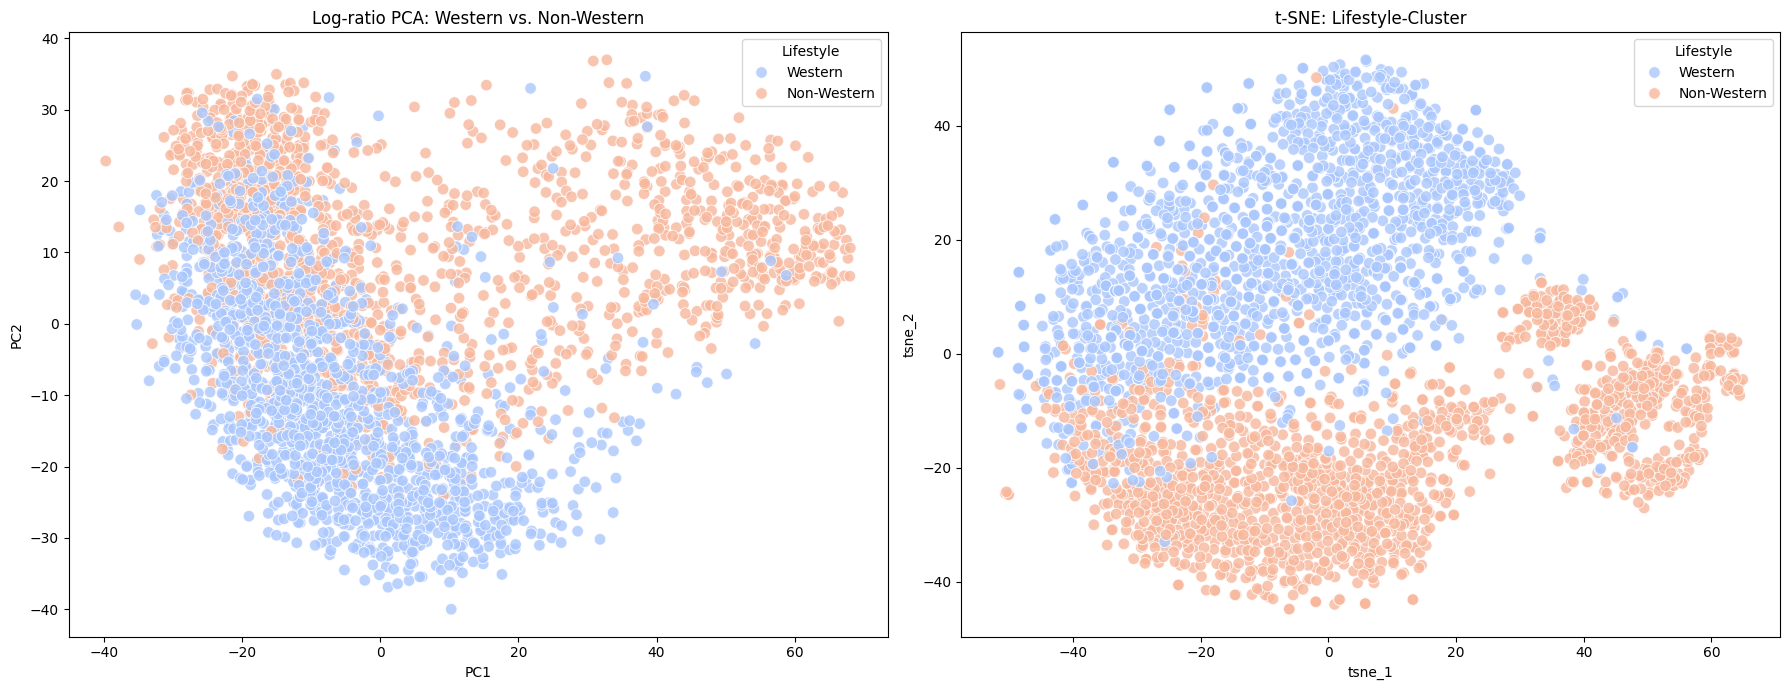

In [11]:
# 1. Lifestyle-Mapping definieren
lifestyle_map = {
    'Austria': 'Western', 'Denmark': 'Western', 'Spain': 'Western', 
    'Finland': 'Western', 'France': 'Western', 'UK': 'Western', 
    'Germany': 'Western', 'Italy': 'Western', 'Luxembourg': 'Western', 'Sweden': 'Western',
    'USA': 'Western',
    'China': 'Non-Western', 'India': 'Non-Western', 'Japan': 'Non-Western', 
    'Mongolia': 'Non-Western', 'Thailand': 'Non-Western',
    'Peru': 'Non-Western', 'Madagascar': 'Non-Western', 
    'Tanzania': 'Non-Western', 'Fiji': 'Non-Western'
}

# Neue Spalte 'Lifestyle' erstellen
df['Lifestyle'] = df['Geography'].map(lifestyle_map)

# Labels für die Analyse aktualisieren
labels = df['Lifestyle']

# 2. PCA durchführen (auf den bereits vorhandenen X-Daten)
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
df_pca['Lifestyle'] = labels

# 3. t-SNE durchführen
tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=42)
X_tsne = tsne.fit_transform(X_pca)

df_tsne = pd.DataFrame(X_tsne, columns=['tsne_1', 'tsne_2'])
df_tsne['Lifestyle'] = labels

# 4. Visualisierung
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot PCA nach Lifestyle
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Lifestyle', ax=ax1, palette='coolwarm', s=70, alpha=0.8)
ax1.set_title('Log-ratio PCA: Western vs. Non-Western')

# Plot t-SNE nach Lifestyle
sns.scatterplot(data=df_tsne, x='tsne_1', y='tsne_2', hue='Lifestyle', ax=ax2, palette='coolwarm', s=70, alpha=0.8)
ax2.set_title('t-SNE: Lifestyle-Cluster')

plt.tight_layout()
plt.show()